In [2]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score

In [3]:
#Import files to train on and one day to test on

train_files = [
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\CICIDS2017\\Monday-WorkingHours.pcap_ISCX.csv",
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\CICIDS2017\\Tuesday-WorkingHours.pcap_ISCX.csv",
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\CICIDS2017\\Wednesday-workingHours.pcap_ISCX.csv",
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\CICIDS2017\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\CICIDS2017\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\CICIDS2017\\Friday-WorkingHours-Morning.pcap_ISCX.csv",
    
]

test_file = "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\CICIDS2017\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

In [4]:
#Define columns to be dropped due to being the target(Label) or identifiers that could skew results
cols = ["Label", "Flow ID", "Source IP", "Destination IP", "Timestamp"]

#Implement a data preprocessing function that will read a csv, and convert labels into a binary target
def data_process(path: str):

    #Import the csv and remove leading and trailing characters from columns
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    #Standardise uppercasing the target label ensures all become consistent (e.g. All become 'BENIGN')
    df["Label"] = df["Label"].astype(str).str.strip().str.upper()

    #Convert label to a binary target (if "BENIGN" set as 0 else an attack is 1)
    y = df["Label"].apply(lambda x:  0 if ("BENIGN" in x) else 1)

    #Drop the list of columns to create the features
    X = df.drop(columns=[c for c in cols if c in df.columns])

    #Dataset stored infinity values as different types so we replace with NaN
    X = X.replace(["Infinity", "inf", "-Infinity", "-inf", "INFINITY"], np.nan)
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan)

    X = X.fillna(X.median(numeric_only=True))
    X = X.astype(np.float32)

    print("File:", path)
    print("Rows:", len(X), "Attack ratio:", y.mean())

    return X, y

In [5]:
#Process each file independantly using the function above collect and then append them to 
#the respective lists
X_list, y_list = [],[]

for file in train_files:
    X_f, y_f = data_process(file)
    X_list.append(X_f)
    y_list.append(y_f)

#Once appended concatenate (reset indices to make alignment simpler)
X_all = pd.concat(X_list, axis=0)
y_all = pd.concat(y_list, axis=0)

print("\nCombined training set:")
print("X:", X_all.shape, "y:", y_all.shape)
print("Class counts:\n", y_all.value_counts())
print("Attack ratio:", y_all.mean())

File: E:\Project Portfolio\Dissertation\Final-Year-IDS\data\CICIDS2017\Monday-WorkingHours.pcap_ISCX.csv
Rows: 529918 Attack ratio: 0.0
File: E:\Project Portfolio\Dissertation\Final-Year-IDS\data\CICIDS2017\Tuesday-WorkingHours.pcap_ISCX.csv
Rows: 445909 Attack ratio: 0.031026509893274188
File: E:\Project Portfolio\Dissertation\Final-Year-IDS\data\CICIDS2017\Wednesday-workingHours.pcap_ISCX.csv
Rows: 692703 Attack ratio: 0.36476238734349353
File: E:\Project Portfolio\Dissertation\Final-Year-IDS\data\CICIDS2017\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Rows: 170366 Attack ratio: 0.01279598041862813
File: E:\Project Portfolio\Dissertation\Final-Year-IDS\data\CICIDS2017\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Rows: 288602 Attack ratio: 0.00012473926029618645
File: E:\Project Portfolio\Dissertation\Final-Year-IDS\data\CICIDS2017\Friday-WorkingHours-Morning.pcap_ISCX.csv
Rows: 191033 Attack ratio: 0.010291415619290908

Combined training set:
X: (2318531, 78)

In [6]:
#Double checking that train and test have the same feature columns
train_feats = X_all.columns.tolist()

X_test, y_test = data_process(test_file)
X_test = X_test.reindex(columns=train_feats, fill_value=0)
X_test = X_test[train_feats]  # enforce same column order

print("\nHoldout test set:", X_test.shape)
print("Holdout class counts:\n", y_test.value_counts())
print("Holdout attack ratio:", y_test.mean())

File: E:\Project Portfolio\Dissertation\Final-Year-IDS\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Rows: 225745 Attack ratio: 0.5671310549513832

Holdout test set: (225745, 78)
Holdout class counts:
 Label
1    128027
0     97718
Name: count, dtype: int64
Holdout attack ratio: 0.5671310549513832


In [7]:
# For recall + generalization across days, do NOT undersample right now.
# Undersampling removes benign diversity and can worsen temporal generalization.

X_train, y_train = X_all, y_all

In [8]:
# Random Forest model (regularized to improve generalization across days)
model = RandomForestClassifier(
    n_estimators=500,        # more trees -> more stable average
    random_state=42,
    n_jobs=-1,
    class_weight="balanced", # prioritize minority class without throwing away data

    # Regularization knobs (reduce overfitting)
    max_depth=12,            # shallower trees generalize better
    min_samples_leaf=10,     # prevents tiny leaves that "memorize"
    min_samples_split=20,
    max_features="sqrt",

    # Optional: make each tree see only a fraction of samples (extra regularization)
    bootstrap=True,
    max_samples=0.7          # each tree trains on 70% of samples -> helps generalization
)

model.fit(X_train, y_train)
print("Model Trained")

# Quick sanity check: training recall (should NOT be ~1.0 if regularization is working)
train_pred = model.predict(X_train)
print("Training recall:", recall_score(y_train, train_pred))

Model Trained
Training recall: 0.9967231767822113


t=0.50  recall=0.6348  FN=46756  FP=608
t=0.40  recall=0.6356  FN=46655  FP=1112
t=0.35  recall=0.6359  FN=46617  FP=1136
t=0.30  recall=0.6359  FN=46609  FP=1204
t=0.25  recall=0.6367  FN=46514  FP=1251
t=0.20  recall=0.6381  FN=46329  FP=1394
t=0.15  recall=0.6397  FN=46132  FP=2323
t=0.10  recall=0.8185  FN=23241  FP=13339

Classification report:
               precision    recall  f1-score   support

        Safe       0.78      0.86      0.82     97718
   Malicious       0.89      0.82      0.85    128027

    accuracy                           0.84    225745
   macro avg       0.84      0.84      0.84    225745
weighted avg       0.84      0.84      0.84    225745



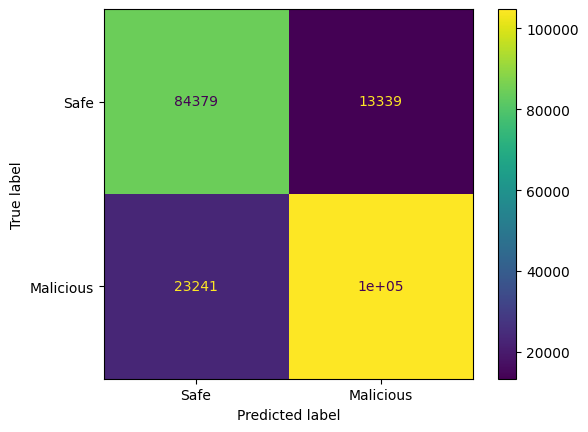

In [9]:
# Evaluate on holdout
proba = model.predict_proba(X_test)[:, 1]  # P(Malicious)

# Sweep thresholds to maximize recall (you choose based on acceptable FP)
for t in [0.50, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]:
    y_pred_t = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    recall = tp / (tp + fn)
    print(f"t={t:.2f}  recall={recall:.4f}  FN={fn}  FP={fp}")

# Pick a threshold that gives you the best recall you can tolerate.
threshold = 0.10
y_pred = (proba >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Safe", "Malicious"]).plot()

print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=["Safe", "Malicious"]))

In [10]:
import os

# Build the combined DataFrame: features + ground truth label in one file
test_export = X_test.copy()                    # already processed float32 features
test_export.insert(0, "y_true", y_test.values) # insert label as first column

# Save to data/ folder alongside your CICIDS CSVs
save_dir = r"E:\Project Portfolio\Dissertation\Final-Year-IDS\data"
save_path = os.path.join(save_dir, "test_set.csv")

test_export.to_csv(save_path, index=False)

print(f"Test set saved: {save_path}")
print(f"Rows : {len(test_export)}")
print(f"Cols : {len(test_export.columns)}  (1 label + {X_test.shape[1]} features)")
print(f"Attack ratio: {y_test.mean():.4f}")

Test set saved: E:\Project Portfolio\Dissertation\Final-Year-IDS\data\test_set.csv
Rows : 225745
Cols : 79  (1 label + 78 features)
Attack ratio: 0.5671


In [ ]:
for file in train_files:
    df = pd.read_csv(file)
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Check if Label column exists
    if "Label" not in df.columns:
        print(f"{file} -> No 'Label' column found. Columns are:")
        print(df.columns)
        print("\n")
        continue
    
    # Standardise label formatting
    df["Label"] = df["Label"].astype(str).str.strip().str.upper()
    
    print("File:", file)
    print(df["Label"].value_counts())
    print("\n")

In [3]:
# Model 2 (Training With DDoS subset)

train_files2 = [
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\Monday-WorkingHours.pcap_ISCX.csv",
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\Tuesday-WorkingHours.pcap_ISCX.csv",
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"
    
]

test_file2 = "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\Wednesday-workingHours.pcap_ISCX.csv"

In [ ]:
#Process each file independantly using the function above collect and then append them to 
#the respective lists
X2_list, y2_list = [],[]

for file in train_files2:
    X_f, y_f = data_process(file)
    X2_list.append(X_f)
    y2_list.append(y_f)

#Once appended concatenate (reset indices to make alignment simpler)
X2_all = pd.concat(X2_list, axis=0)
y2_all = pd.concat(y2_list, axis=0)

print("\nCombined training set:")
print("X:", X2_all.shape, "y:", y2_all.shape)
print("Class counts:\n", y2_all.value_counts())
print("Attack ratio:", y2_all.mean())

In [ ]:
#Double checking that train and test have the same feature columns
train_feats2 = X2_all.columns.tolist()

X2_test, y2_test = data_process(test_file2)
X2_test = X2_test.reindex(columns=train_feats2, fill_value=0)
X2_test = X2_test[train_feats2]  # enforce same column order

print("\nHoldout test set:", X2_test.shape)
print("Holdout class counts:\n", y2_test.value_counts())
print("Holdout attack ratio:", y2_test.mean())

In [8]:
X2_train, y2_train = X2_all, y2_all

In [ ]:
# Random Forest model (regularized to improve generalization across days)
model2 = RandomForestClassifier(
    n_estimators=500,        # more trees -> more stable average
    random_state=42,
    n_jobs=-1,
    class_weight="balanced", # prioritize minority class without throwing away data

    # Regularization knobs (reduce overfitting)
    max_depth=12,            # shallower trees generalize better
    min_samples_leaf=10,     # prevents tiny leaves that "memorize"
    min_samples_split=20,
    max_features="sqrt",

    # Optional: make each tree see only a fraction of samples (extra regularization)
    bootstrap=True,
    max_samples=0.7          # each tree trains on 70% of samples -> helps generalization
)

model2.fit(X2_train, y2_train)
print("Model Trained")

# Quick sanity check: training recall (should NOT be ~1.0 if regularization is working)
train_pred2 = model2.predict(X2_train)
print("Training recall:", recall_score(y2_train, train_pred2))

In [ ]:
# Evaluate on holdout
proba2 = model2.predict_proba(X2_test)[:, 1]  # P(Malicious)

# Sweep thresholds to maximize recall (you choose based on acceptable FP)
for t in [0.50, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]:
    y2_pred_t = (proba2 >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y2_test, y2_pred_t).ravel()
    recall = tp / (tp + fn)
    print(f"t={t:.2f}  recall={recall:.4f}  FN={fn}  FP={fp}")

# Pick a threshold that gives you the best recall you can tolerate.
threshold = 0.20
y2_pred = (proba2 >= threshold).astype(int)

cm = confusion_matrix(y2_test, y2_pred)
ConfusionMatrixDisplay(cm, display_labels=["Safe", "Malicious"]).plot()

print("\nClassification report:\n", classification_report(y2_test, y2_pred, target_names=["Safe", "Malicious"]))

In [ ]:
print("Train features:", X2_train.shape[1])
print("Test features :", X2_test.shape[1])
print("Feature sets identical:", list(X2_train.columns) == list(X2_test.columns))

In [ ]:
zero_cols = (X2_test.sum(axis=0) == 0).sum()
print("Number of all-zero columns in X2_test:", zero_cols)

In [ ]:
imp = pd.Series(model2.feature_importances_, index=X2_train.columns).sort_values(ascending=False)
top = imp.head(10).index

print(pd.DataFrame({
    "train_mean": X2_train[top].mean(),
    "test_mean":  X2_test[top].mean(),
    "train_std":  X2_train[top].std(),
    "test_std":   X2_test[top].std(),
}))

In [9]:
import joblib
from datetime import datetime

model_version = "v1.0"
threshold = 0.10
timestamp = datetime.now().strftime("%Y-%m-%d")

bundle = {
    "model": model,
    "features": X_train.columns.tolist(),
    "threshold": threshold,
    "version": model_version,
    "created_at": timestamp,
}

save_path = r"E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\models\\IDS_RF_v1.0"

joblib.dump(bundle, save_path)

print("Model Successfully saved to:\n", save_path)

Model Successfully saved to:
 E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\models\\IDS_RF_v1.0
